In [2]:
import sys
print(sys.version)

3.13.7 | packaged by Anaconda, Inc. | (main, Sep  9 2025, 19:54:17) [Clang 17.0.6 ]


In [4]:
import sys
import os
# Get the current working directory
current_dir = '/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/' #os.getcwd()

# Add the src directory to the Python path
src_path = os.path.join(os.path.dirname(current_dir), 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

import numpy as np
import matplotlib.pyplot as plt
import random
import sys
import os
import cv2
from GridMetrics import GridScorer, circle_mask, get_even_odd_times, GridParameters, create_new_result_dir, load_grid_metrics_from_pickle
import json
import matplotlib
from matplotlib.lines import Line2D
import scipy
import time

In [17]:
rat = 'r2'
mod = '1'
exp = 'sleep' # sleep or OF
save_flag = True

general_results_working_directory = os.path.join(current_dir, 'results')
session_results_directory = create_new_result_dir(general_results_working_directory, rat+mod)
G = GridParameters(rat, mod, exp = exp, precompute=True)
print("keys:", G.__dict__.keys())

Directory /Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/results/r21 already exists
keys: dict_keys(['rat', 'mod', 'exp', 'delta', 'x', 'y', 'spikes', 'n_neurons', 'Scorer', 'grid_scores', 'mask_radius', 'orientation', 'spacing'])


In [18]:
results_path = session_results_directory
predictive_grid_cells = np.load(results_path + '/predictive_grid_cells.npy')
predictive_grid_cell_ids = np.argwhere(predictive_grid_cells == True)
grid_scores = np.load(results_path + '/grid_scores.npy')

In [19]:
delta_values = np.arange(-40, 40, 2)
grid_cell_thresh = 1.0

g0 = grid_scores[np.argwhere(delta_values == 0), :]
grid_cells = g0.flatten() > grid_cell_thresh
grid_cell_ids = np.argwhere(grid_cells == True).flatten()

non_grid_non_predictive_grid_cell_ids = np.argwhere((grid_cells + predictive_grid_cells) == False)

In [20]:
N = G.n_neurons
T = len(G.spikes[0])
spikes = np.zeros((N, T))

sampling_rate = 0.02
moving_window = int(1 / sampling_rate) # smooth spikes across 1 second
T_smoothed = T - moving_window + 1
spikes_smoothed = np.zeros((N, T_smoothed))

for ii in range(N):
    spikes[ii, :] = G.spikes[ii]
    spikes_smoothed[ii, :] = np.convolve(spikes[ii, :], np.ones(moving_window), 'valid') / moving_window

spike_rate = np.sum(spikes, axis = 1) / (T * sampling_rate)


0.7969102115350566
1.1181782275308827


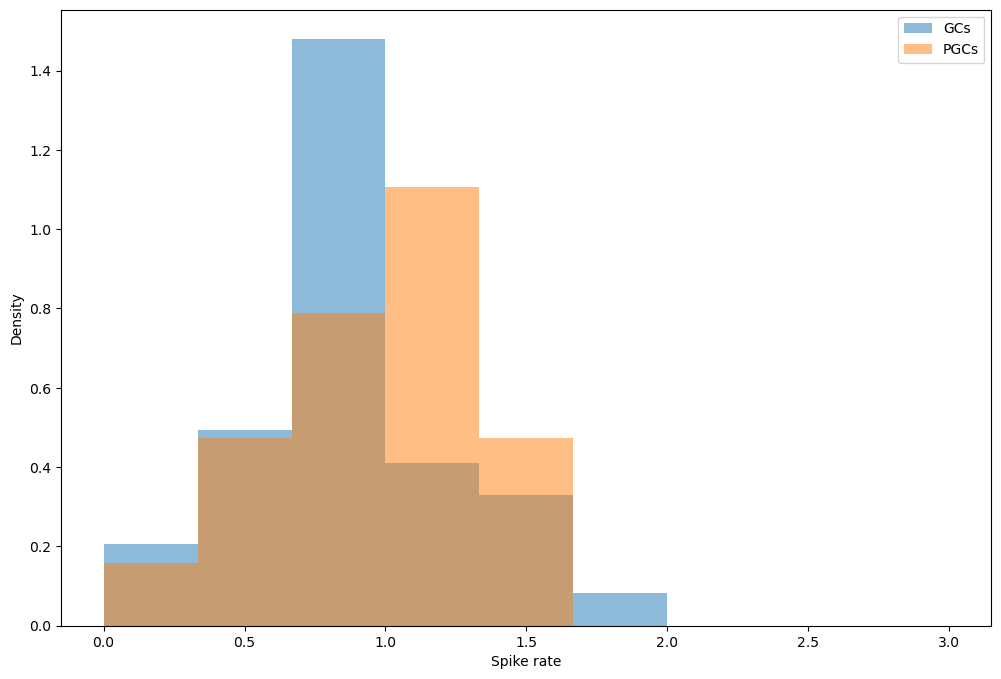

In [21]:
plt.figure(figsize=(12, 8))
plt.hist(spike_rate[grid_cell_ids], bins = np.linspace(0, 3, 10), density = True, label = 'GCs', alpha = 0.5)
plt.hist(spike_rate[predictive_grid_cell_ids], bins = np.linspace(0, 3, 10), density = True, label = 'PGCs', alpha = 0.5)
plt.xlabel('Spike rate')
plt.ylabel('Density')
plt.legend()

print(np.median(spike_rate[grid_cell_ids]))
print(np.median(spike_rate[predictive_grid_cell_ids]))

In [100]:
corr_bin = 60 # bin size for correlation (in seconds) #30
bin_size = int(corr_bin / sampling_rate)
n_bins = 100
pairwise_corr = np.zeros((N, N, n_bins)) * np.nan

for ii in range(N):
    print(ii)
    for jj in range(N):
        if ii > jj:
            for kk in range(n_bins):
                bin_start = np.random.randint(0, T_smoothed - bin_size)
                x = spikes_smoothed[ii, bin_start:(bin_start + bin_size)]
                y = spikes_smoothed[jj, bin_start:(bin_start + bin_size)]
                while np.sum(x) == 0 and np.sum(y) == 0:
                    bin_start = np.random.randint(0, T_smoothed - bin_size)
                    x = spikes_smoothed[ii, bin_start:(bin_start + bin_size)]
                    y = spikes_smoothed[jj, bin_start:(bin_start + bin_size)]
                pairwise_corr[ii, jj, kk] = scipy.stats.pearsonr(x, y).statistic

0
1
2
3
4
5


/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_94734/848703043.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pairwise_corr[ii, jj, kk] = scipy.stats.pearsonr(x, y).statistic


6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188


In [101]:
np.save(results_path + '/pairwise_corr_' + str(exp) + '.npy', pairwise_corr)

In [102]:
pairwise_corr_grid_cells = np.zeros((len(grid_cell_ids), len(grid_cell_ids), n_bins))

for ii in range(len(grid_cell_ids)):
    for jj in range(len(grid_cell_ids)):
        if ii == jj:
            pairwise_corr_grid_cells[ii, jj, :] = np.nan
        else:
            pairwise_corr_grid_cells[ii, jj, :] = pairwise_corr[grid_cell_ids[ii], grid_cell_ids[jj], :]

/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_94734/2923315255.py:2: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pairwise_corr_grid_cells, axis=2))


Text(0.5, 1.0, 'Grid-grid correlations')

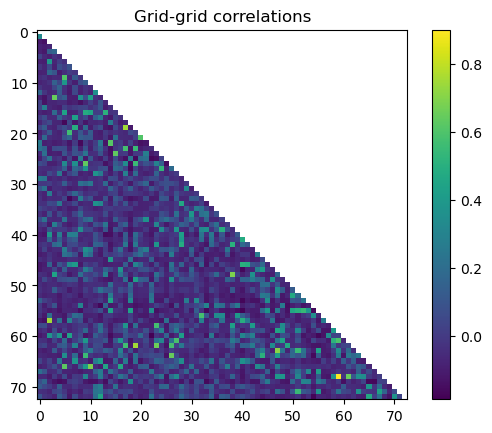

In [103]:
plt.figure()
plt.imshow(np.nanmedian(pairwise_corr_grid_cells, axis=2))
plt.colorbar()
plt.title('Grid-grid correlations')

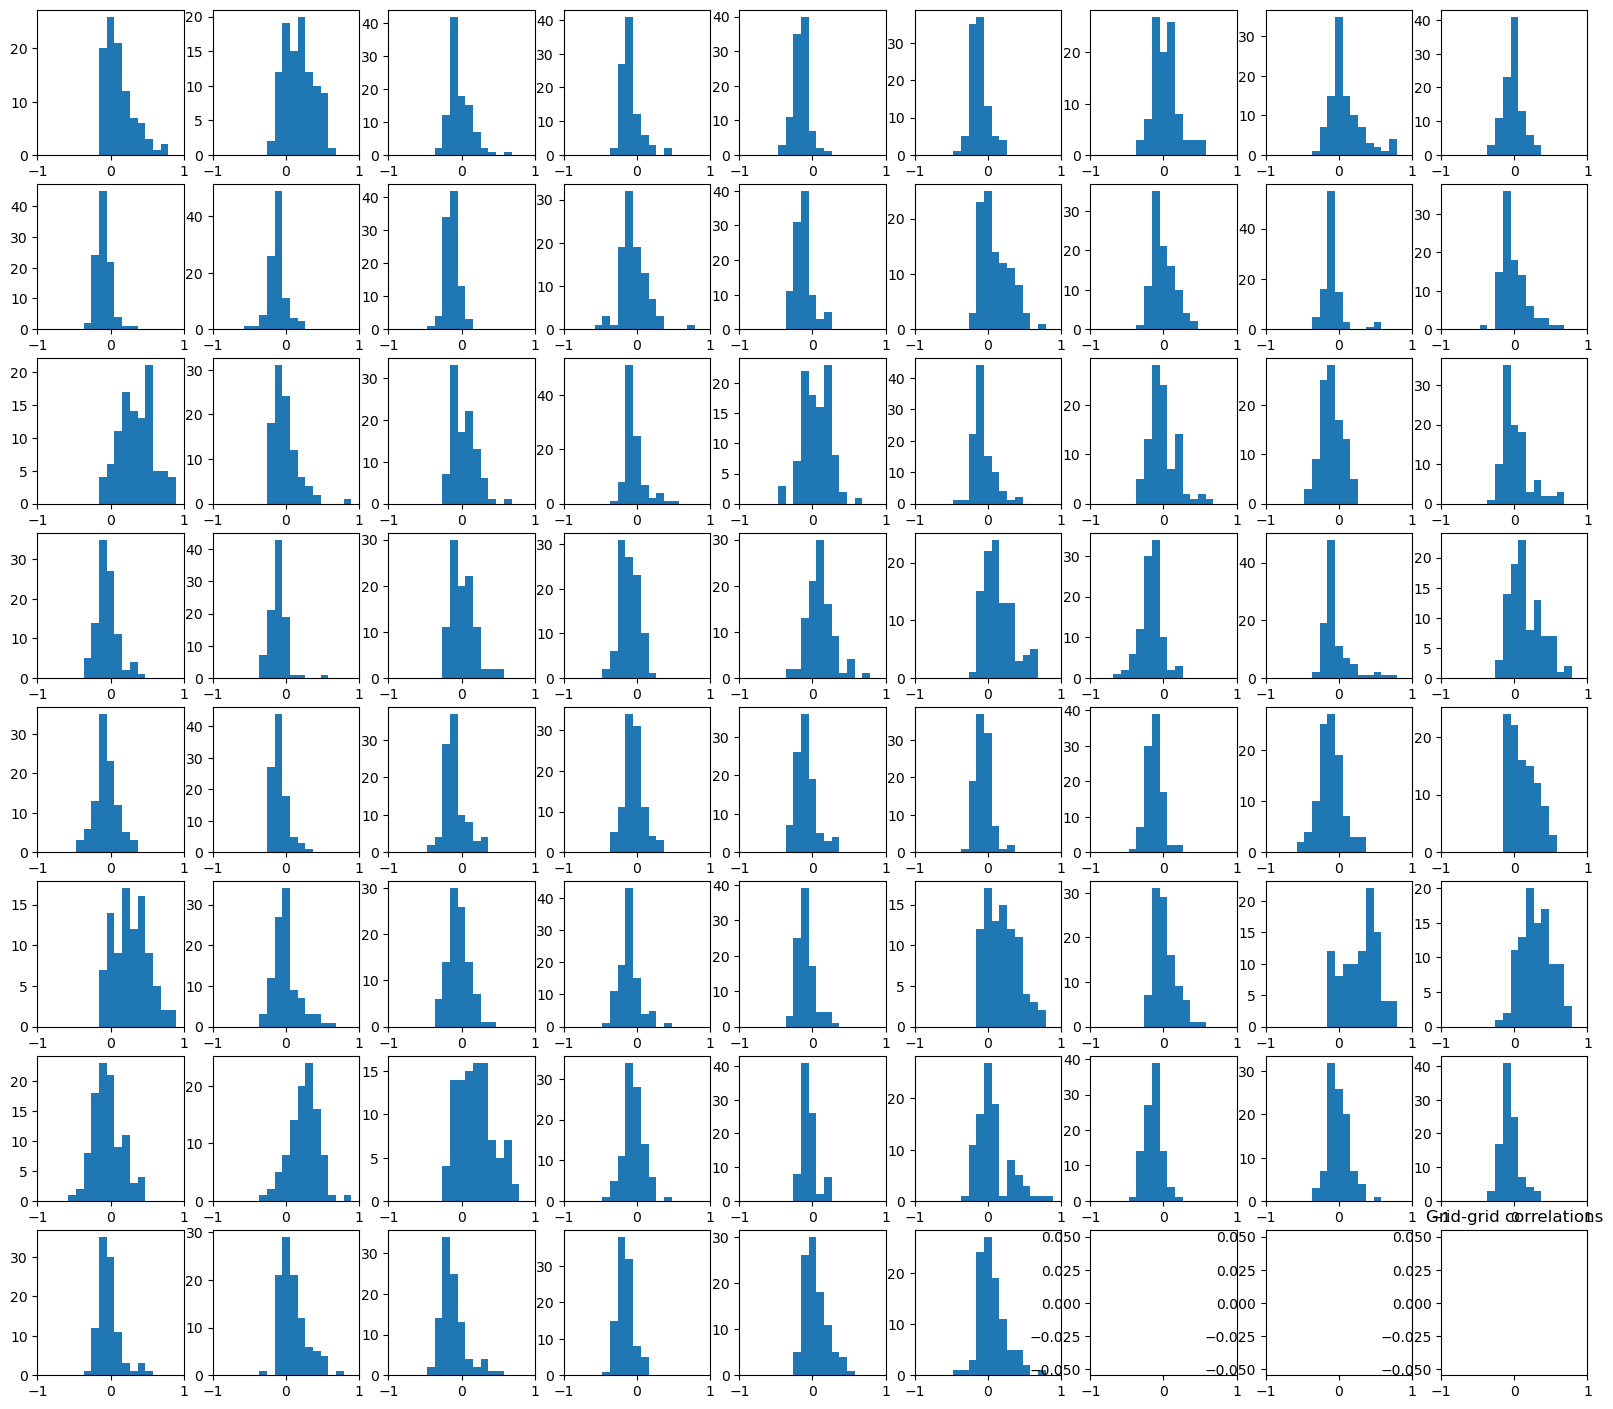

In [104]:
fig = plt.figure(figsize = (20, 20))
for ii in range(len(grid_cell_ids) - 1):
    plt.subplot(int(np.sqrt(len(grid_cell_ids))) + 1, int(np.sqrt(len(grid_cell_ids))) + 1, ii + 1)
    plt.hist(pairwise_corr_grid_cells[-4, ii, :], bins = np.linspace(-1.0, 1.0, 20))
    plt.xlim(-1, 1)
plt.title('Grid-grid correlations')
if save_flag:
    plt.savefig(results_path + '/grid_pairwise_corr_' + str(exp) + '.png')
    plt.savefig(results_path + '/grid_pairwise_corr_' + str(exp) + '.svg', format = 'svg')

In [105]:
pairwise_corr_predictive_grid_cells = np.zeros((len(predictive_grid_cell_ids), len(predictive_grid_cell_ids), n_bins))

for ii in range(len(predictive_grid_cell_ids)):
    for jj in range(len(predictive_grid_cell_ids)):
        if ii == jj:
            pairwise_corr_predictive_grid_cells[ii, jj, :] = np.nan
        else:
            pairwise_corr_predictive_grid_cells[ii, jj, :] = pairwise_corr[predictive_grid_cell_ids[ii], predictive_grid_cell_ids[jj], :]

/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_94734/1391826953.py:2: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pairwise_corr_predictive_grid_cells, axis=2))


Text(0.5, 1.0, 'Pred-pred correlations')

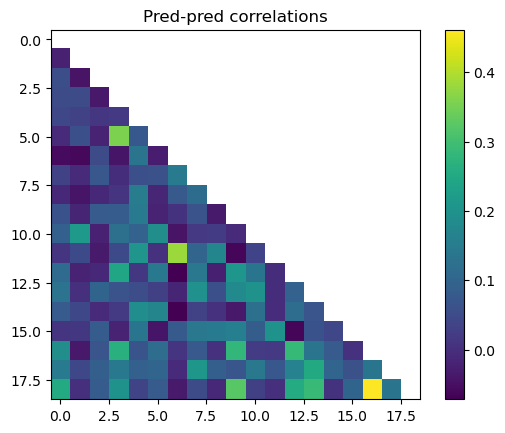

In [106]:
plt.figure()
plt.imshow(np.nanmedian(pairwise_corr_predictive_grid_cells, axis=2))
plt.colorbar()
plt.title('Pred-pred correlations')

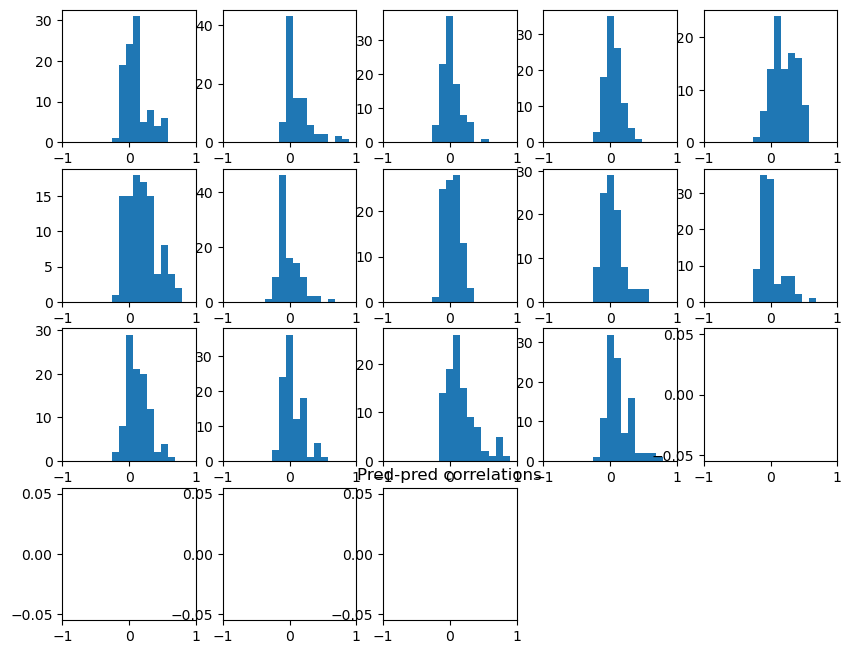

In [107]:
fig = plt.figure(figsize = [10, 10])
for ii in range(len(predictive_grid_cell_ids) - 1):
    plt.subplot(int(np.sqrt(len(predictive_grid_cell_ids))) + 1, int(np.sqrt(len(predictive_grid_cell_ids))) + 1, ii + 1)
    plt.hist(pairwise_corr_predictive_grid_cells[-5, ii, :], bins = np.linspace(-1.0, 1.0, 20))
    plt.xlim(-1, 1)
plt.title('Pred-pred correlations')
if save_flag:
    plt.savefig(results_path + '/predictive_grid_pairwise_corr_' + str(exp) + '.png')
    plt.savefig(results_path + '/predictive_grid_pairwise_corr_' + str(exp) + '.svg', format = 'svg')

In [108]:
pairwise_corr_grid_predictive_grid_cells = np.zeros((len(grid_cell_ids), len(predictive_grid_cell_ids), n_bins))

for ii in range(len(grid_cell_ids)):
    for jj in range(len(predictive_grid_cell_ids)):
            pairwise_corr_grid_predictive_grid_cells[ii, jj, :] = pairwise_corr[np.max([grid_cell_ids[ii], predictive_grid_cell_ids[jj][0]]), np.min([grid_cell_ids[ii], predictive_grid_cell_ids[jj][0]]), :]

Text(0.5, 1.0, 'Grid-pred correlations')

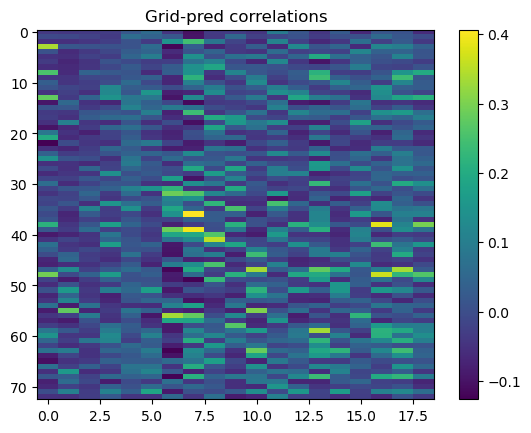

In [109]:
plt.figure()
plt.imshow(np.nanmedian(pairwise_corr_grid_predictive_grid_cells, axis=2), aspect='auto')
plt.colorbar()
plt.title('Grid-pred correlations')

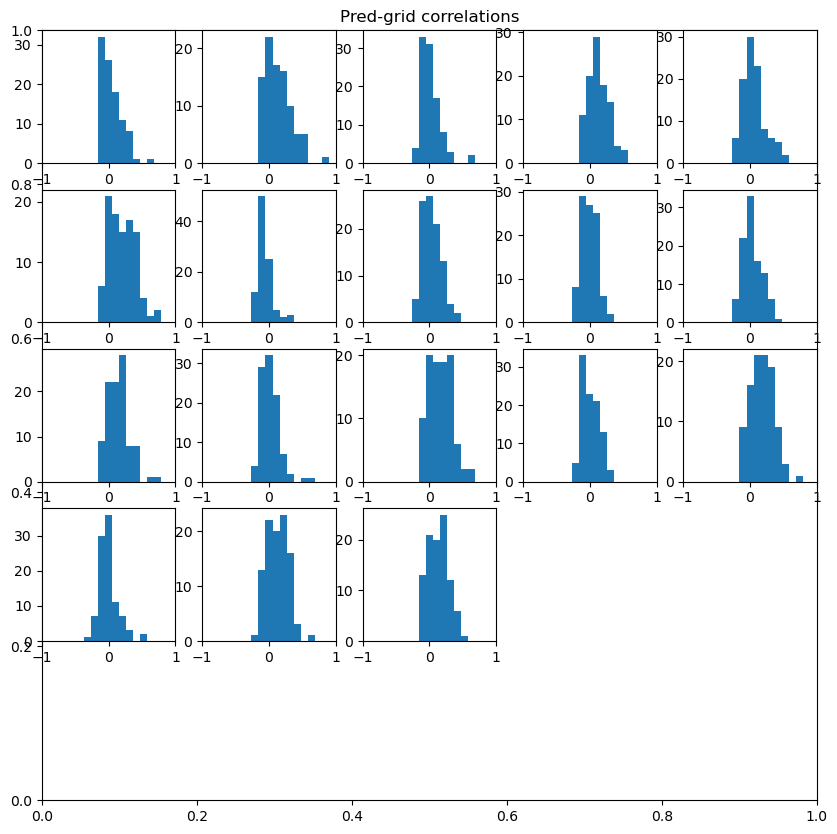

In [110]:
fig = plt.figure(figsize=[10, 10])
plt.title('Pred-grid correlations')
for ii in range(len(predictive_grid_cell_ids) - 1):
    plt.subplot(int(np.sqrt(len(predictive_grid_cell_ids))) + 1, int(np.sqrt(len(predictive_grid_cell_ids))) + 1,
                ii + 1)
    plt.hist(pairwise_corr_grid_predictive_grid_cells[-2, ii, :], bins=np.linspace(-1.0, 1.0, 20))
    plt.xlim(-1, 1)
if save_flag:
    plt.savefig(results_path + '/grid_predictive_grid_pairwise_corr_' + str(exp) + '.png')
    plt.savefig(results_path + '/grid_predictive_grid_pairwise_corr_' + str(exp) + '.svg', format='svg')

In [111]:
pairwise_corr_grid_non_cells = np.zeros((len(grid_cell_ids), len(non_grid_non_predictive_grid_cell_ids), n_bins))

for ii in range(len(grid_cell_ids)):
    for jj in range(len(non_grid_non_predictive_grid_cell_ids)):
            pairwise_corr_grid_non_cells[ii, jj, :] = pairwise_corr[np.max([grid_cell_ids[ii], non_grid_non_predictive_grid_cell_ids[jj][0]]), np.min([grid_cell_ids[ii], non_grid_non_predictive_grid_cell_ids[jj][0]]), :]

Text(0.5, 1.0, 'Grid-non correlations')

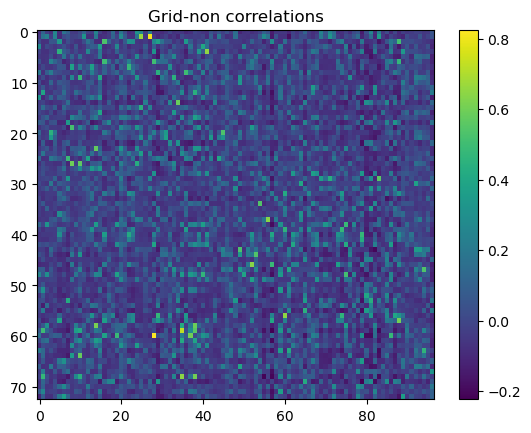

In [112]:
plt.figure()
plt.imshow(np.nanmedian(pairwise_corr_grid_non_cells, axis=2), aspect='auto')
plt.colorbar()
plt.title('Grid-non correlations')

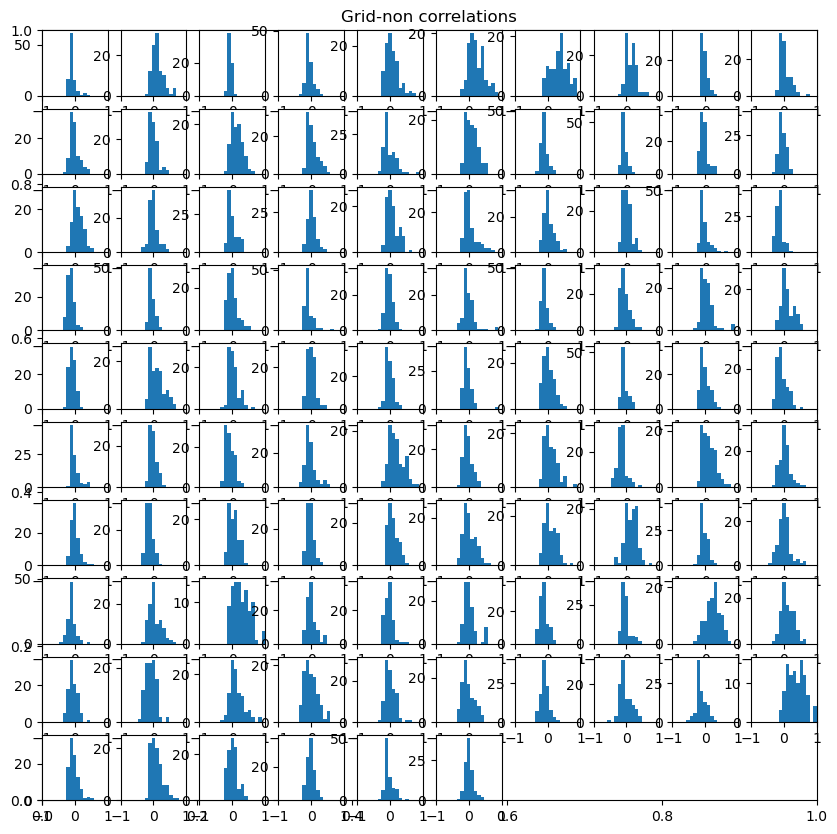

In [113]:
fig = plt.figure(figsize=[10, 10])
plt.title('Grid-non correlations')
for ii in range(len(non_grid_non_predictive_grid_cell_ids) - 1):
    plt.subplot(int(np.sqrt(len(non_grid_non_predictive_grid_cell_ids))) + 1, int(np.sqrt(len(non_grid_non_predictive_grid_cell_ids))) + 1,
                ii + 1)
    plt.hist(pairwise_corr_grid_non_cells[-1, ii, :], bins=np.linspace(-1.0, 1.0, 20))
    plt.xlim(-1, 1)
if save_flag:
    plt.savefig(results_path + '/grid_non_pairwise_corr_' + str(exp) + '.png')
    plt.savefig(results_path + '/grid_non_pairwise_corr_' + str(exp) + '.svg', format='svg')

0.14908440302093912
0.15582282370807954
0.1543635824780768
0.14639053530241913


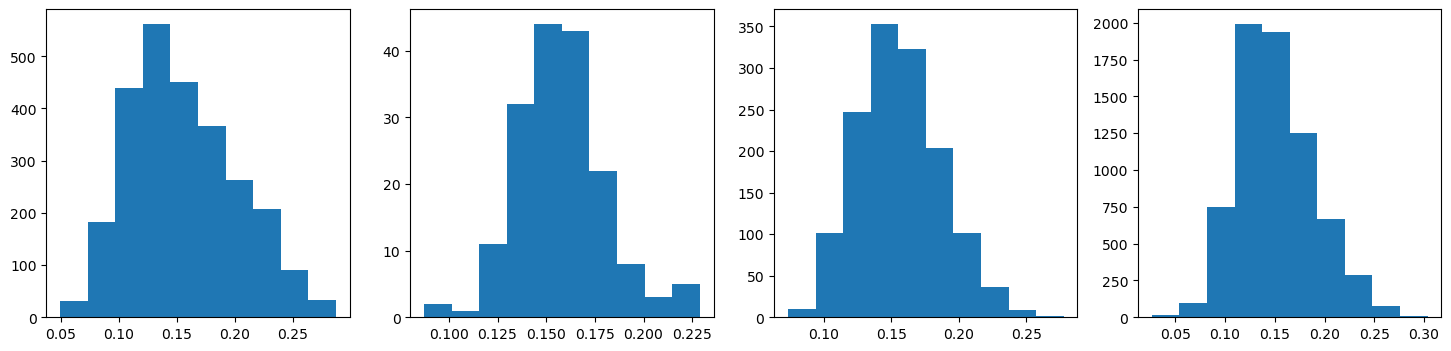

In [114]:
plt.figure(figsize = (18, 4))
plt.subplot(1, 4, 1)
plt.hist(np.nanstd(pairwise_corr_grid_cells, axis=2).flatten())
print(np.nanmedian(np.nanstd(pairwise_corr_grid_cells, axis=2).flatten()))

plt.subplot(1, 4, 2)
plt.hist(np.nanstd(pairwise_corr_predictive_grid_cells, axis=2).flatten())
print(np.nanmedian(np.nanstd(pairwise_corr_predictive_grid_cells, axis=2).flatten()))

plt.subplot(1, 4, 3)
plt.hist(np.nanstd(pairwise_corr_grid_predictive_grid_cells, axis=2).flatten())
print(np.nanmedian(np.nanstd(pairwise_corr_grid_predictive_grid_cells, axis=2).flatten()))

plt.subplot(1, 4, 4)
plt.hist(np.nanstd(pairwise_corr_grid_non_cells, axis=2).flatten())
print(np.nanmedian(np.nanstd(pairwise_corr_grid_non_cells, axis=2).flatten()))


/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_94734/3748701398.py:2: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  kur_grid = scipy.stats.kurtosis(pairwise_corr_grid_cells, axis = 2, fisher=True, nan_policy


0.7662306388063793
-0.053146398522802674
0.2986671111743764


/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_94734/3748701398.py:10: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  kur_predictive_grid = scipy.stats.kurtosis(pairwise_corr_predictive_grid_cells, axis = 2, fisher=True, nan_policy


0.3994440128161867


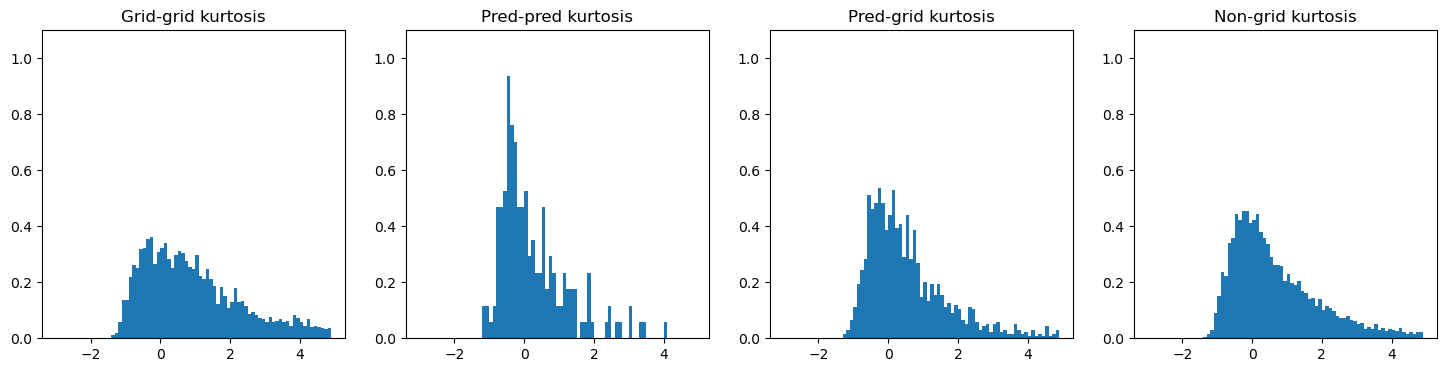

In [115]:
plt.figure(figsize = (18, 4))
kur_grid = scipy.stats.kurtosis(pairwise_corr_grid_cells, axis = 2, fisher=True, nan_policy
 = 'omit')
plt.subplot(1, 4, 1)
plt.hist(kur_grid.flatten(), bins = np.arange(-3, 5, 0.1), density = True)
plt.title('Grid-grid kurtosis')
plt.ylim(0.0, 1.1)
print(np.nanmedian(kur_grid))

kur_predictive_grid = scipy.stats.kurtosis(pairwise_corr_predictive_grid_cells, axis = 2, fisher=True, nan_policy
 = 'omit')
plt.subplot(1, 4, 2)
plt.hist(kur_predictive_grid.flatten(), bins = np.arange(-3, 5, 0.1), density = True)
plt.title('Pred-pred kurtosis')
plt.ylim(0.0, 1.1)
print(np.nanmedian(kur_predictive_grid))

kur_grid_predictive_grid = scipy.stats.kurtosis(pairwise_corr_grid_predictive_grid_cells, axis = 2, fisher=True, nan_policy
 = 'omit')
plt.subplot(1, 4, 3)
plt.hist(kur_grid_predictive_grid.flatten(), bins = np.arange(-3, 5, 0.1), density = True)
plt.title('Pred-grid kurtosis')
plt.ylim(0.0, 1.1)
print(np.nanmedian(kur_grid_predictive_grid))

kur_grid_non = scipy.stats.kurtosis(pairwise_corr_grid_non_cells, axis = 2, fisher=True, nan_policy
 = 'omit')
plt.subplot(1, 4, 4)
plt.hist(kur_grid_non.flatten(), bins = np.arange(-3, 5, 0.1), density = True)
plt.title('Non-grid kurtosis')
plt.ylim(0.0, 1.1)
print(np.nanmedian(kur_grid_non))

if save_flag:
    plt.savefig(results_path + '/kurtosis_' + str(exp) + '.png')
    plt.savefig(results_path + '/kurtosis_' + str(exp) + '.svg', format='svg')

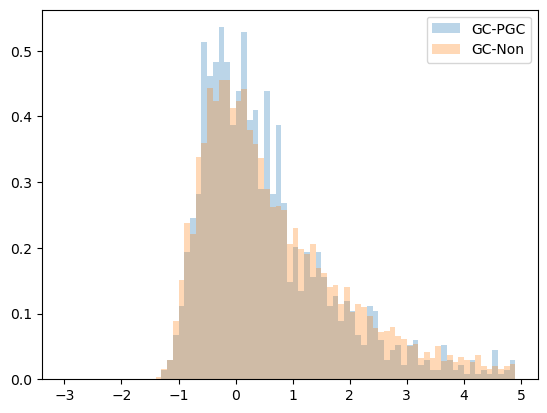

In [116]:
plt.hist(kur_grid_predictive_grid.flatten(), bins = np.arange(-3, 5, 0.1), alpha = 0.3, density = True, label = 'GC-PGC')
plt.hist(kur_grid_non.flatten(), bins = np.arange(-3, 5, 0.1), alpha = 0.3, density = True, label = 'GC-Non')
plt.legend()


In [95]:
pred_grid_non_grid_sig_stats = scipy.stats.kstest(kur_grid_non.flatten(), kur_grid_predictive_grid.flatten())
print(pred_grid_non_grid_sig_stats.pvalue)

kur_grid = kur_grid.flatten()
kur_grid = kur_grid[~np.isnan(kur_grid)]
grid_non_grid_sig_stats = scipy.stats.kstest(kur_grid_non.flatten(), kur_grid)
print(grid_non_grid_sig_stats.pvalue)

kur_predictive_grid = kur_predictive_grid.flatten()
kur_predictive_grid = kur_predictive_grid[~np.isnan(kur_predictive_grid)]
pred_pred_pre_grid_sig_stats = scipy.stats.kstest(kur_predictive_grid, kur_grid_predictive_grid.flatten())
print(pred_pred_pre_grid_sig_stats.pvalue)

3.7772410728394574e-06
6.905738241755086e-08
2.6376954227369176e-12


/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_94734/13844995.py:2: RuntimeWarning: All-NaN slice encountered
  range_grid = np.nanmax(pairwise_corr_grid_cells, axis = 2) - np.nanmin(pairwise_corr_grid_cells, axis = 2)
/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_94734/13844995.py:8: RuntimeWarning: All-NaN slice encountered
  range_predictive_grid = np.nanmax(pairwise_corr_predictive_grid_cells, axis = 2) - np.nanmin(pairwise_corr_predictive_grid_cells, axis = 2)


0.7440363040021423
0.7000266790528287
0.7366706930456782
0.7384167049804001


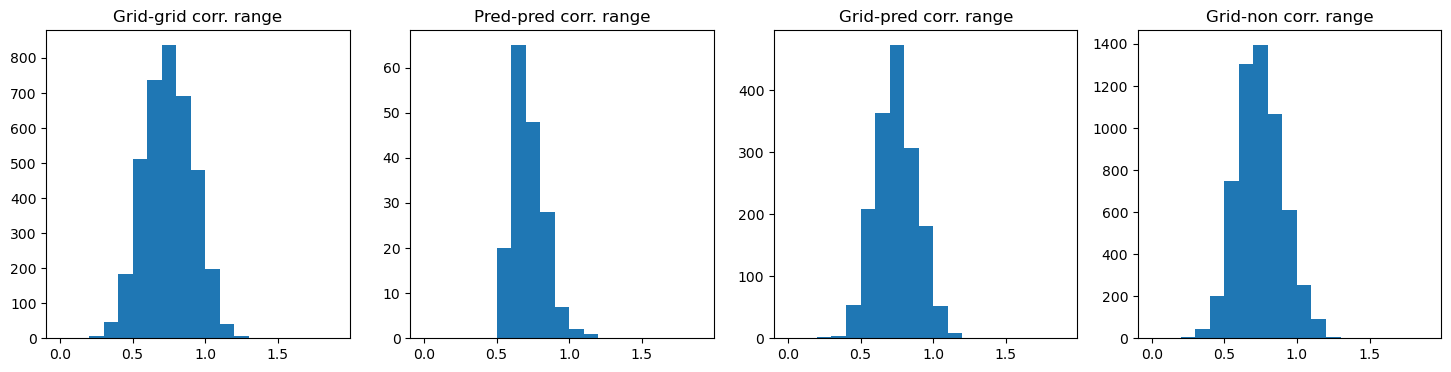

In [27]:
plt.figure(figsize = (18, 4))
range_grid = np.nanmax(pairwise_corr_grid_cells, axis = 2) - np.nanmin(pairwise_corr_grid_cells, axis = 2)
plt.subplot(1, 4, 1)
plt.hist(range_grid.flatten(), bins = np.arange(0, 2, 0.1))
plt.title('Grid-grid corr. range')
print(np.nanmedian(range_grid))

range_predictive_grid = np.nanmax(pairwise_corr_predictive_grid_cells, axis = 2) - np.nanmin(pairwise_corr_predictive_grid_cells, axis = 2)
plt.subplot(1, 4, 2)
plt.hist(range_predictive_grid.flatten(), bins = np.arange(0, 2, 0.1))
plt.title('Pred-pred corr. range')
print(np.nanmedian(range_predictive_grid))

range_grid_predictive_grid = np.nanmax(pairwise_corr_grid_predictive_grid_cells, axis = 2) - np.nanmin(pairwise_corr_grid_predictive_grid_cells, axis = 2)
plt.subplot(1, 4, 3)
plt.hist(range_grid_predictive_grid.flatten(), bins = np.arange(0, 2, 0.1))
plt.title('Grid-pred corr. range')
print(np.nanmedian(range_grid_predictive_grid))

range_grid_non = np.nanmax(pairwise_corr_grid_non_cells, axis = 2) - np.nanmin(pairwise_corr_grid_non_cells, axis = 2)
plt.subplot(1, 4, 4)
plt.hist(range_grid_non.flatten(), bins = np.arange(0, 2, 0.1))
plt.title('Grid-non corr. range')
print(np.nanmedian(range_grid_non))